In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df= pd.read_excel("C:\\Users\\Dell\\OneDrive\\Desktop\\STATISTICS\\Data analysis\\project\\swiggy\\swiggy_data.xlsx")

In [4]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [5]:
df['Category'].head(20)

0                  Snack
1            Recommended
2            Recommended
3            Recommended
4            Recommended
5            Recommended
6            Recommended
7            Recommended
8     North Indian Gravy
9     North Indian Gravy
10    North Indian Gravy
11    North Indian Gravy
12    North Indian Gravy
13    North Indian Gravy
14    North Indian Gravy
15    North Indian Gravy
16    North Indian Gravy
17    North Indian Gravy
18    North Indian Gravy
19    North Indian Gravy
Name: Category, dtype: str

In [6]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='str')

In [7]:
df.shape

(197430, 10)

In [8]:
df.isnull().sum().sum()

0

In [9]:
# total sales
total_sales = round(df['Price (INR)'].sum())
print(f"Total Sales: {round(df['Price (INR)'].sum(),2)}")

Total Sales: 53012505.77


In [10]:
# Average Rating
print(f"Average Rating: {round(df['Rating'].mean(),2)}")

Average Rating: 4.34


In [11]:
# Average order Value
print(f"Average order value: {round(total_sales/df.shape[0],2)}")

Average order value: 268.51


In [12]:
# Ratings Count
print(f"Total number of customer reviews: {df['Rating Count'].sum()}")

Total number of customer reviews: 5591574


In [13]:
# Total Orders
print(f"Total Orders: {df.shape[0]}")

Total Orders: 197430


### Charts

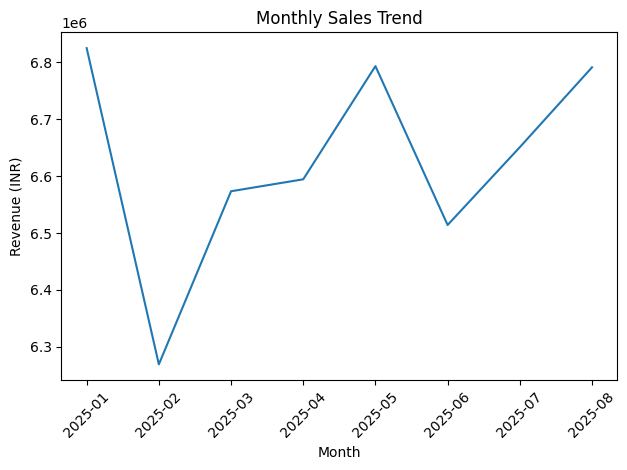

In [14]:
# Monthly Sales Trend
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period("M").astype(str)
monthly_revenue = df.groupby('YearMonth')['Price (INR)'].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Price (INR)'])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()

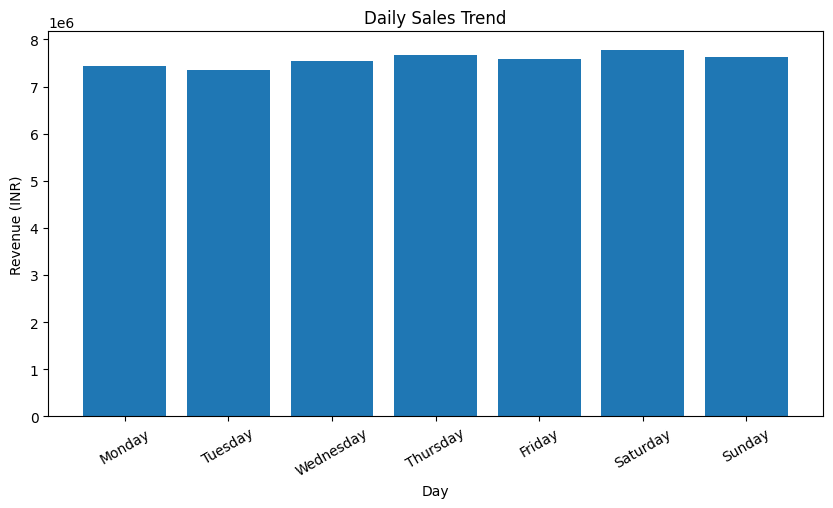

In [15]:
# Daily Sales Trend
df['DayName'] = pd.to_datetime(df['Order Date']).dt.day_name()

daily_revenue = (
    df.groupby('DayName')['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Sales Trend")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()
    

In [16]:
# Total Sales by Food Type (Veg vs Non-Veg)
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biriyani", "kabab", "kebab",
    "non_veg", "non veg"
]

df['Food Category'] = np.where(
    df['Dish Name'].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

food_revenue=df.groupby("Food Category")['Price (INR)'].sum().reset_index()
food_revenue

,Food Category,Price (INR)
0,Non-Veg,18205776.43
1,Veg,34806729.34


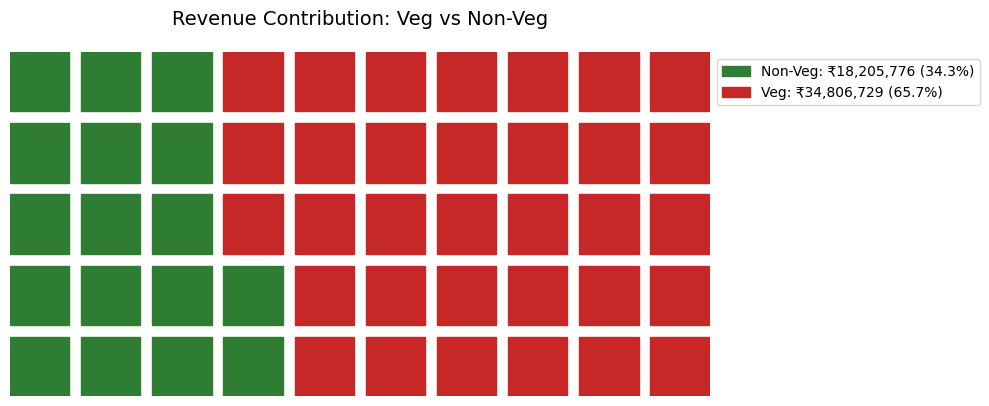

In [18]:
from pywaffle import Waffle

values = food_revenue['Price (INR)'].values
categories = food_revenue['Food Category'].values
colors = ['#2E7D32', '#C62828']

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,
    columns=10,
    values=values,
    labels=[f"{cat}: ₹{val:,.0f} ({val/values.sum()*100:.1f}%)" 
            for cat, val in zip(categories, values)],
    colors=colors,
    legend={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    figsize=(10, 5)
)

plt.title('Revenue Contribution: Veg vs Non-Veg', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

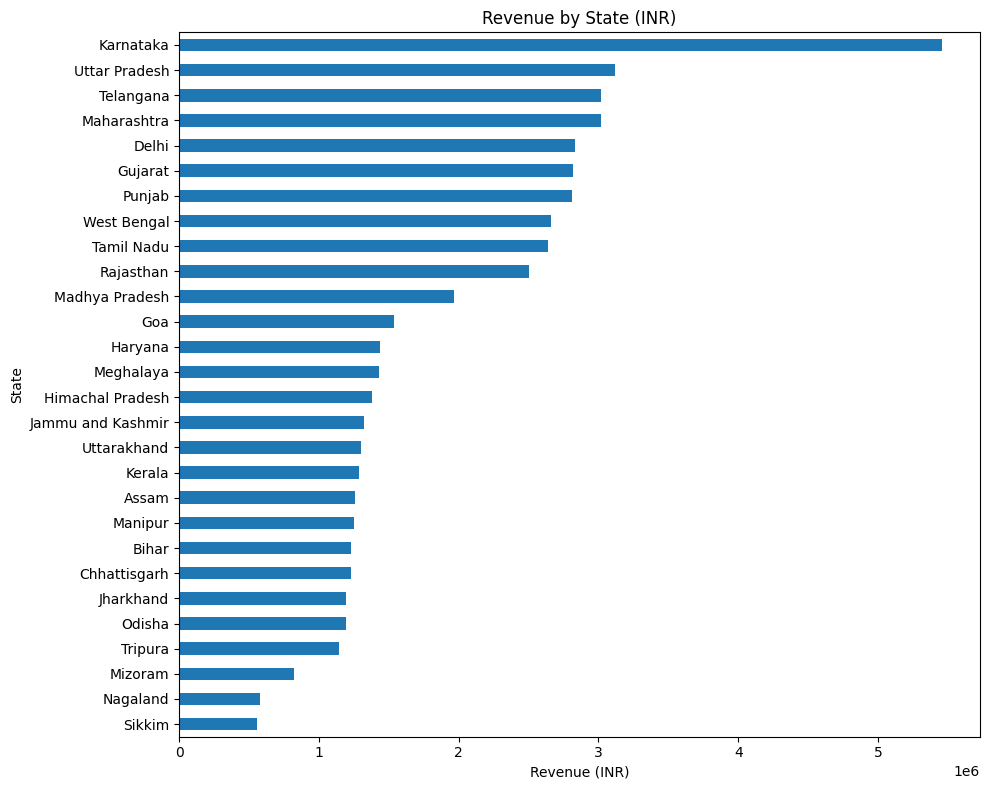

In [34]:
# Total Sales by State

state_revenue = df.groupby("State")["Price (INR)"].sum().sort_values()

state_revenue.plot(kind='barh', figsize=(10, 8), title="Revenue by State (INR)")
plt.xlabel("Revenue (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

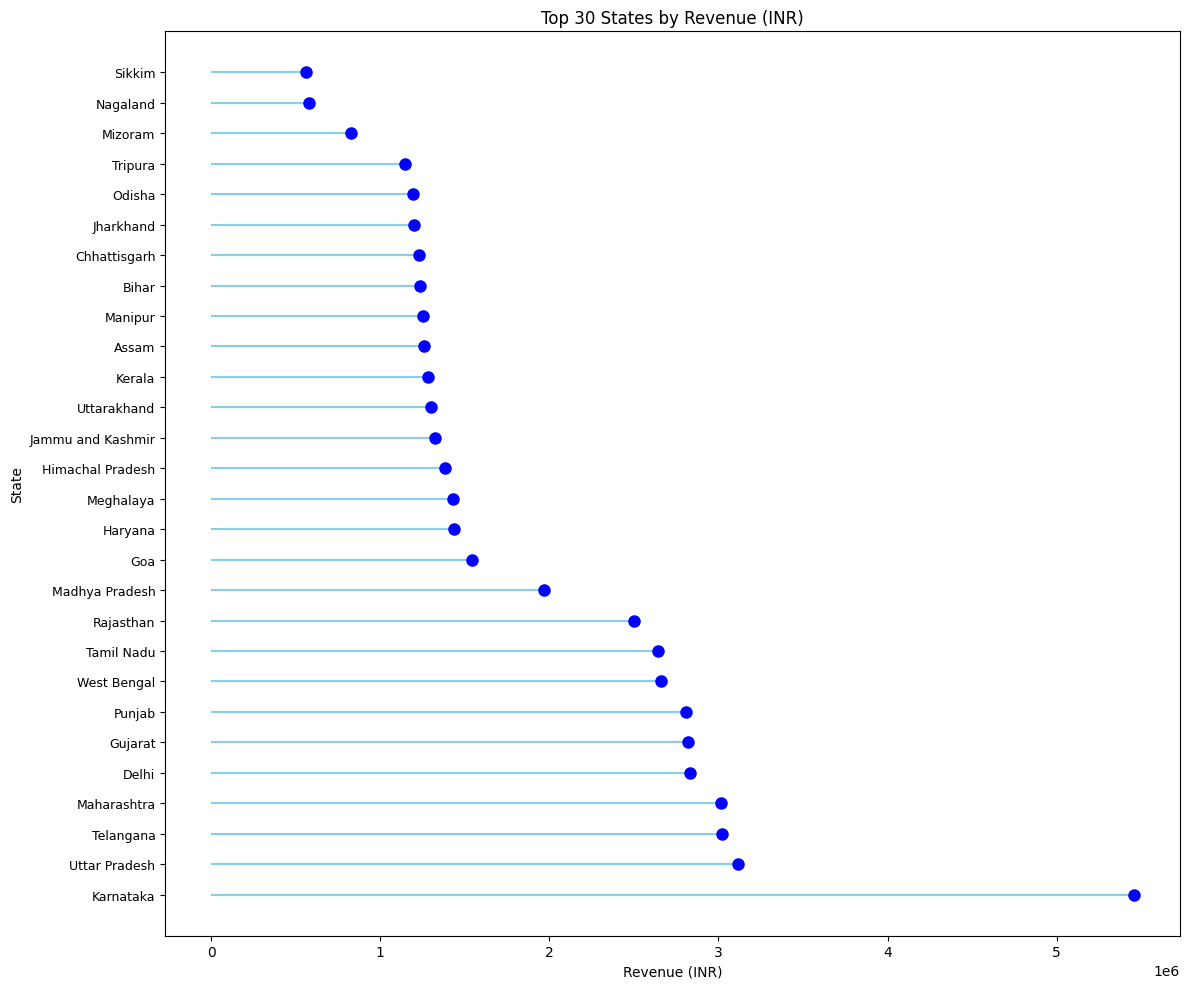

In [33]:
state_revenue = df.groupby("State")["Price (INR)"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 10))
plt.hlines(y=range(len(state_revenue)), xmin=0, xmax=state_revenue.values, color='skyblue')
plt.plot(state_revenue.values, range(len(state_revenue)), 'o', markersize=8, color='blue')
plt.yticks(range(len(state_revenue)), state_revenue.index, fontsize=9)
plt.title("Top 30 States by Revenue (INR)")
plt.xlabel("Revenue (INR)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

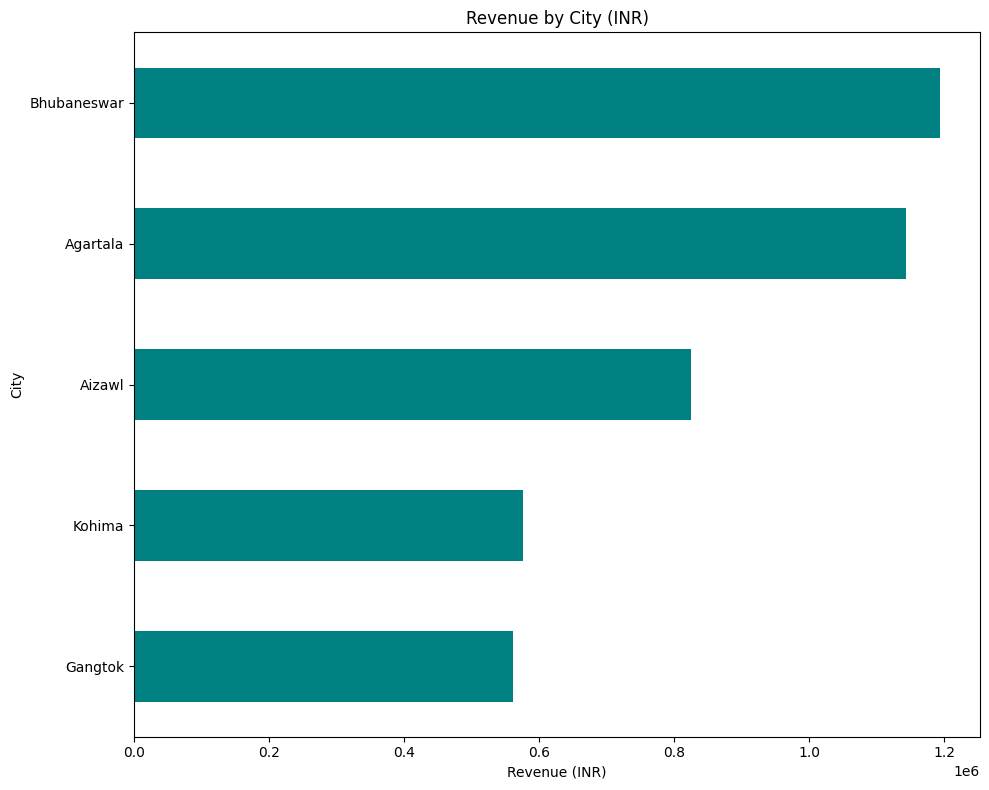

In [39]:
# Top 5 Cities by Sales
top_city = df.groupby("City")["Price (INR)"].sum().sort_values().head(5)

top_city.plot(kind='barh', figsize=(10, 8), title="Revenue by City (INR)", color='teal')
plt.xlabel("Revenue (INR)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

In [43]:
cd "C:\Users\Dell\OneDrive\Desktop\STATISTICS\Data analysis\project\swiggy"

C:\Users\Dell\OneDrive\Desktop\STATISTICS\Data analysis\project\swiggy
